# 3 &middot; Build your own noise model &mdash; which terms matter?

Now **you** drive the analysis. Pick your favourite pulsar from the bundled MPTA-DR2
array, switch noise terms on and off, and use the corner plot to judge which ones
the data actually require.

As in notebook 2 we assemble the model from **Discovery's `signals` tools directly**,
but here we wrap it in a small `build_model(...)` function with `True`/`False` flags.
Nothing is hidden inside a high-level wrapper, so you can copy this function straight
into your own analysis scripts and adapt it.

A Discovery pulsar model is just a **list of components**:

* always included: the **data** (`psr.residuals`), the **timing model**
  (`makegp_timing`), and per-backend **measurement (white) noise**
  (`makenoise_measurement` &rarr; EFAC + EQUAD);
* optional terms you switch on below.

The menu of optional terms (each is one `signals.*` call):

| flag | physical process | how it's built | parameters |
|------|------------------|----------------|------------|
| `ecorr` | per-epoch correlated white noise | `makegp_ecorr` | `log10_ecorr` |
| `red` | achromatic spin noise | `makegp_fourier` | `red_noise_log10_A`, `red_noise_gamma` |
| `dm` | dispersion-measure variations ($\nu^{-2}$) | `makegp_fourier` (DM basis) | `dm_gp_log10_A`, `dm_gp_gamma` |
| `chrom` | other chromatic noise (free index $\alpha$) | `makegp_fourier` (chrom basis) | `chrom_gp_log10_A`, `chrom_gp_gamma`, `chrom_gp_alpha` |

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax, jax.random
import discovery as ds                       # importing discovery enables float64 in jax
import discovery.signals as signals
import discovery.likelihood as likelihood
import discovery.prior as prior
import discovery.samplers.numpyro as ds_numpyro

DATADIR = "./my_feathers"

# Which pulsars are available?
avail = sorted(os.path.basename(f)[:-8] for f in glob.glob(os.path.join(DATADIR, "*.feather")))
print(len(avail), "pulsars available, e.g.:", avail[:8])

4 pulsars available, e.g.: ['J0613-0200', 'J1017-7156', 'J1744-1134', 'J1909-3744']


### ① Choose your pulsar

In [2]:
psrname = "J0613-0200"        # <-- change me! (must be in the list above)
psr = ds.Pulsar.read_feather(os.path.join(DATADIR, psrname + ".feather"))
print(f"{psr.name}: {len(psr.toas)} TOAs, "
      f"{signals.getspan(psr)/86400/365.25:.1f} yr, "
      f"{psr.freqs.min():.0f}-{psr.freqs.max():.0f} MHz")

J0613-0200: 3067 TOAs, 4.3 yr, 908-1659 MHz


### ② A reusable model builder

This function assembles the component list yourself, term by term, using only
`discovery` tools. Read it &mdash; the white noise and timing model are always present,
and every optional block is a single `signals.*` call guarded by a flag. This is
exactly the pattern you'd put in your own script.

In [3]:
def build_model(psr, flags, max_cadence_days=60):
    '''Build a single-pulsar PulsarLikelihood from discovery signals.

    `flags` is a dict of booleans choosing the optional noise terms.
    Returns (model, components).
    '''
    # Number of Fourier frequency components from the data span and chosen cadence
    Tspan = signals.getspan(psr)
    components = int(Tspan / (max_cadence_days * 86400.0))

    comps = []

    # --- always included --------------------------------------------------
    comps.append(psr.residuals)                                  # the data
    comps.append(signals.makegp_timing(psr, svd=True))          # timing model (marginalised)
    comps.append(signals.makenoise_measurement(psr, tnequad=True))  # EFAC + EQUAD per backend

    # --- optional terms ---------------------------------------------------
    if flags.get("ecorr"):
        comps.append(signals.makegp_ecorr(psr))                 # per-epoch correlated white noise
    if flags.get("red"):
        comps.append(signals.makegp_fourier(psr, signals.powerlaw,
                                            components=components, name="red_noise"))
    if flags.get("dm"):
        comps.append(signals.makegp_fourier(psr, signals.powerlaw, components=components,
                                            fourierbasis=signals.dmfourierbasis, name="dm_gp"))
    if flags.get("chrom"):
        comps.append(signals.makegp_fourier(psr, signals.powerlaw, components=components,
                                            fourierbasis=signals.dmfourierbasis_alpha, name="chrom_gp"))

    # Wrap the components into a likelihood and collect the free parameters
    model = likelihood.PulsarLikelihood(comps)
    #pars = []
    #for c in comps:
    #    if hasattr(c, "params"):
    #        pars.extend(c.params)
    #model.all_params = list(pars)
    #model.logL.params = sorted(set(pars))
    return model, comps

### ③ Choose your noise terms

Flip these flags to decide what goes in the model. Start with `ecorr` + `red` + `dm`,
sample, look at the corner plot, then add `chrom` and see whether it is significant.

In [4]:
noise_flags = dict(
    ecorr=True,    # per-epoch correlated white noise
    red=True,      # achromatic spin noise
    dm=True,       # DM noise (freq^-2)
    chrom=False,   # general chromatic noise (free alpha)
)

max_cadence_days = 60    # larger -> fewer GP components -> faster

model, comps = build_model(psr, noise_flags, max_cadence_days=max_cadence_days)

print("Free parameters in this model:")
for p in model.logL.params:
    print("   ", p)

Free parameters in this model:
    J0613-0200_KAT_MKBF_efac
    J0613-0200_KAT_MKBF_log10_ecorr
    J0613-0200_KAT_MKBF_log10_tnequad
    J0613-0200_chrom_gp_alpha
    J0613-0200_chrom_gp_gamma
    J0613-0200_chrom_gp_log10_A
    J0613-0200_dm_gp_gamma
    J0613-0200_dm_gp_log10_A
    J0613-0200_red_noise_gamma
    J0613-0200_red_noise_log10_A


### ④ Set the priors

Each free parameter gets a flat (uniform) prior. We set the ranges explicitly so you
can see &mdash; and tweak &mdash; exactly what is assumed. These are also the bounds we'll
overlay on the corner plot to test significance.

In [5]:
prior.priordict_standard.update({
    # white noise
    r"(.*_)?efac":             [0.5, 2.0],
    r"(.*_)?log10_tnequad":    [-10, -5],
    r"(.*_)?log10_ecorr":      [-10, -5],
    # red (spin) noise
    r"(.*_)?red_noise_log10_A.*": [-18, -11],
    r"(.*_)?red_noise_gamma.*":   [0, 7],
    # DM noise
    r"(.*_)?dm_gp_log10_A":    [-18, -11],
    r"(.*_)?dm_gp_gamma":      [0, 7],
    # chromatic noise
    r"(.*_)?chrom_gp_log10_A": [-18, -11],
    r"(.*_)?chrom_gp_gamma":   [0, 7],
    r"(.*_)?chrom_gp_alpha":   [2.0, 14.0],
})
print("Priors for this model's parameters:")
for p in model.logL.params:
    print(f"   {p:42s} {prior.getprior_uniform(p, {})}")

Priors for this model's parameters:
   J0613-0200_KAT_MKBF_efac                   [0.5, 2.0]
   J0613-0200_KAT_MKBF_log10_ecorr            [-10, -5]
   J0613-0200_KAT_MKBF_log10_tnequad          [-8.5, -5]
   J0613-0200_chrom_gp_alpha                  [2.0, 14.0]
   J0613-0200_chrom_gp_gamma                  [0, 7]
   J0613-0200_chrom_gp_log10_A                [-18, -11]
   J0613-0200_dm_gp_gamma                     [0, 7]
   J0613-0200_dm_gp_log10_A                   [-18, -11]
   J0613-0200_red_noise_gamma                 [0, 7]
   J0613-0200_red_noise_log10_A               [-18, -11]


### ⑤ Sample

We build the numpyro model with `makemodel_transformed` (efficient unconstrained
HMC), run NUTS, read the chain back with `sampler.to_df()`, and evaluate the
log-likelihood ourselves at each sample.

In [6]:
npmodel = ds_numpyro.makemodel_transformed(model.logL)
sampler = ds_numpyro.makesampler_nuts(npmodel, num_warmup=200, num_samples=500)

key = jax.random.PRNGKey(123456789)
sampler.run(key)

chain = sampler.to_df()
chain = chain[[p for p in model.logL.params]].copy()      # keep just the model parameters
# chain["logl"] = np.asarray(jax.lax.map(model.logL, {p: chain[p].values for p in model.logL.params}))

outdir = "./results"
os.makedirs(outdir, exist_ok=True)
tag = "_".join(k for k, v in noise_flags.items() if v) or "white"
save_base = os.path.join(outdir, f"{psrname}_{tag}")
chain.to_pickle(save_base + ".pickle")
print("saved", save_base + ".pickle", " shape:", chain.shape)

sample: 100%|████████████| 700/700 [31:01<00:00,  2.66s/it, 63 steps of size 5.09e-02. acc. prob=0.95]


saved ./results/J0613-0200_ecorr_red_dm_chrom.pickle  shape: (500, 10)


### ⑥ Corner plot &mdash; and the significance test

We build the corner plot **by hand** with the `corner` package, straight from the
posterior DataFrame.

The key trick: **overlay the prior**. Each parameter is sampled from a flat prior.
If the posterior just fills the prior range, or piles up against the lower amplitude
edge, the data say nothing &mdash; that term is **not significant**. A clear peak pulled
away from the prior edges means the process is **detected**. The dashed red lines
mark the prior bounds on the amplitude (`log10_A`) parameters.

/opt/build_psrsoft/workspace/micromamba/envs/IPTA_Env/lib/python3.11/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/pulsar/.config', but the default location, /home/pulsar/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


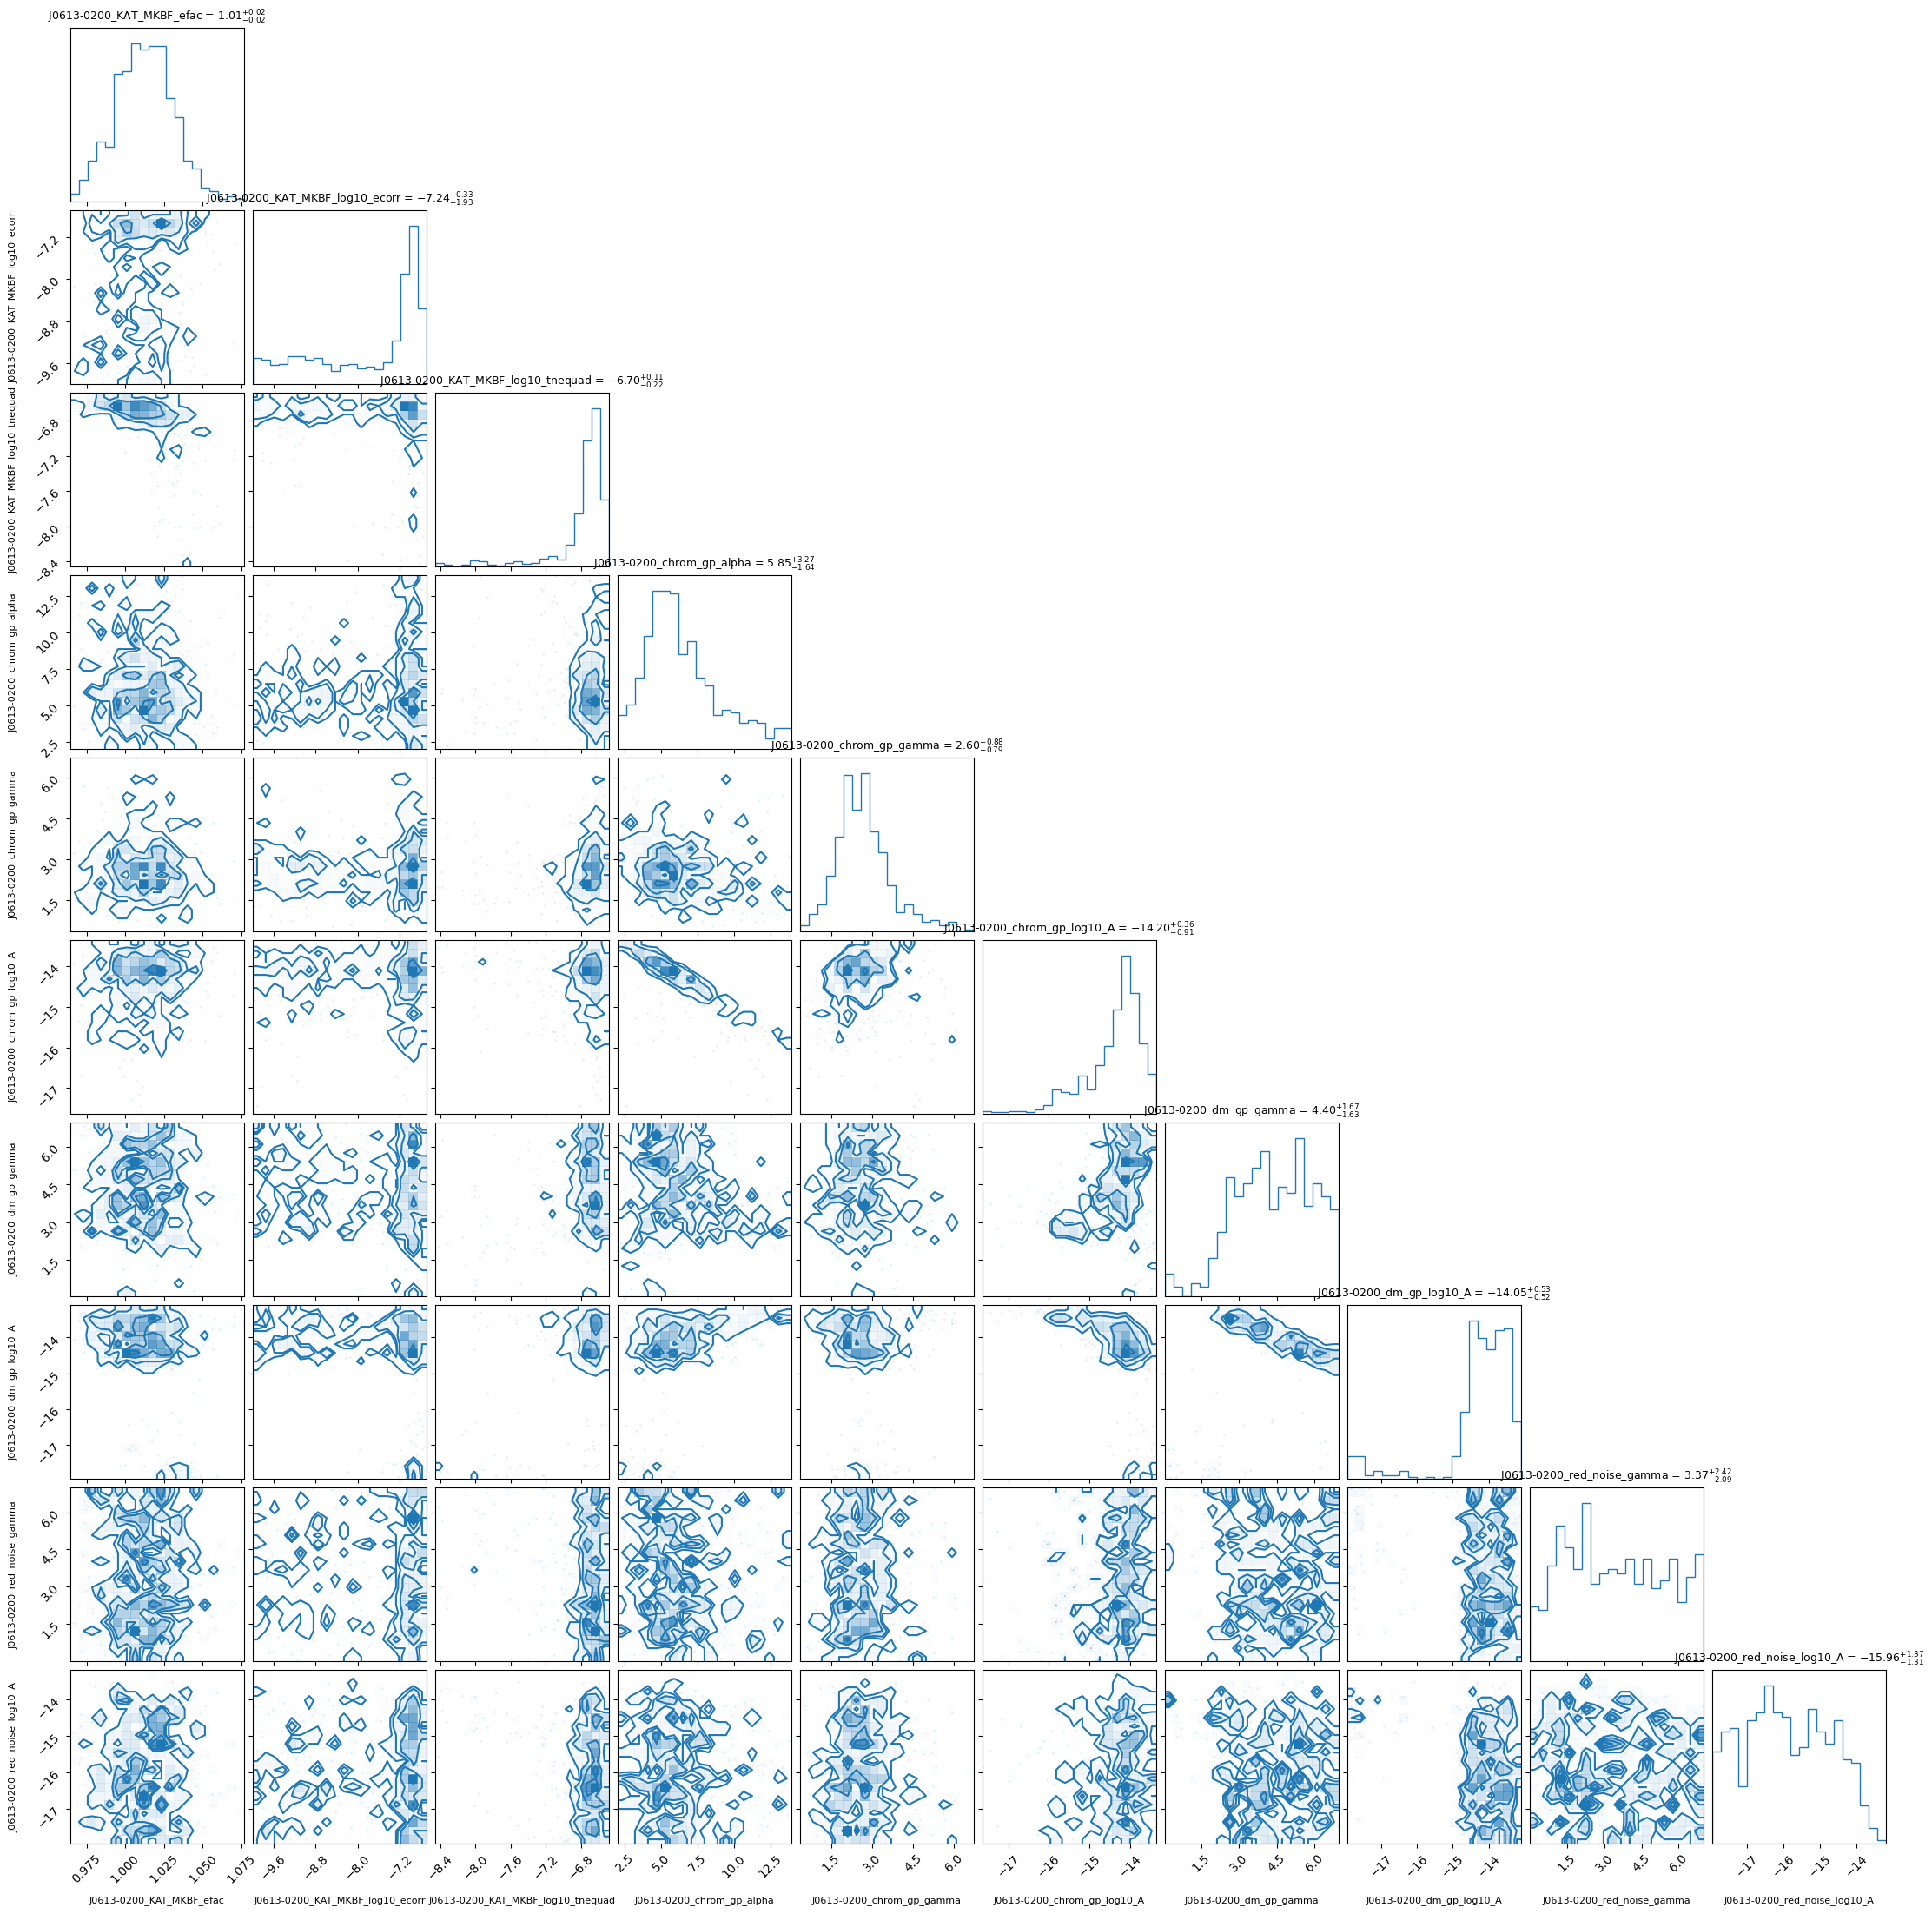

In [7]:
import corner

labels = [c for c in chain.columns if c != "logl"]
fig = corner.corner(
    chain[labels].values,
    labels=labels,
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 9},
    label_kwargs={"fontsize": 8},
    color="C0",
    hist_kwargs={"color": "C0"},
)

# Overlay the flat-prior bounds on the amplitude diagonals as a visual reference.
axes = np.array(fig.axes).reshape(len(labels), len(labels))
for i, lab in enumerate(labels):
    if lab.endswith("log10_A"):
        lo, hi = prior.getprior_uniform(lab, {})
        axes[i, i].axvline(lo, color="crimson", ls="--", lw=1)
        axes[i, i].axvline(hi, color="crimson", ls="--", lw=1)

fig.savefig(save_base + "_corner.png", dpi=120, bbox_inches="tight")
plt.show()

### ⑦ Significance: the Savage&ndash;Dickey Bayes factor

A quantitative significance test to back up the corner plot. The **Savage&ndash;Dickey
density ratio** gives the Bayes factor between a model in which a noise process is
**on** versus **off**, as the ratio of the **prior** to the **posterior** density in
the region where the parameter is effectively inactive.

For an amplitude `log10_A` we treat **`log10_A < -16`** as "off" (the process is
negligible below this). Then

$$\mathcal{B}_{\rm on/off} \;=\;
  \frac{\Pr(\log_{10}A < -16 \,\mid\, \mathrm{prior})}
       {\Pr(\log_{10}A < -16 \,\mid\, \mathrm{posterior})}.$$

If the posterior has pulled its mass **away** from the off-region, the denominator is
small and the Bayes factor is large &mdash; the process is **detected**. If there are
**no** posterior samples in the off-region we can only set a **lower limit**,
$\mathcal{B} > \Pr_{\rm prior}\times N_{\rm samples}$ (we would need at least one
sample to measure the posterior mass).

Rule of thumb: $\mathcal{B}>3$ substantial, $>10$ strong, $>100$ decisive evidence
for the process.

In [8]:
threshold = -16.0    # log10_A below this  =>  process effectively "off"
N = len(chain)

print(f"Savage-Dickey Bayes factors for {psrname}  (off-region: log10_A < {threshold:.0f})\n")
for lab in labels:
    if not lab.endswith("log10_A"):
        continue
    lo, hi = prior.getprior_uniform(lab, {})
    proc = lab.split("_", 1)[1].replace("_log10_A", "")

    # prior probability mass in the off-region (flat prior on [lo, hi])
    edge = min(max(threshold, lo), hi)
    prior_mass = (edge - lo) / (hi - lo)
    if prior_mass == 0:
        print(f"  {proc:12s}  off-region is outside the prior range -- skipped")
        continue

    # posterior probability mass in the off-region
    n_off = int(np.sum(chain[lab].values < threshold))

    if n_off == 0:
        # 0 of N samples below threshold: posterior mass < ~1/N  ->  lower limit
        bf = prior_mass * N
        print(f"  {proc:12s}  B_on/off > {bf:8.1f}   (0/{N} samples off  -> DETECTED)")
    else:
        bf = prior_mass / (n_off / N)
        verdict = ("DETECTED (strong)" if bf > 10 else "substantial" if bf > 3 else
                   "marginal" if bf > 1 else "not significant")
        print(f"  {proc:12s}  B_on/off = {bf:8.2f}   ({n_off}/{N} samples off  -> {verdict})")

Savage-Dickey Bayes factors for J0613-0200  (off-region: log10_A < -16)

  chrom_gp      B_on/off =     9.52   (15/500 samples off  -> substantial)
  dm_gp         B_on/off =     3.66   (39/500 samples off  -> substantial)
  red_noise     B_on/off =     0.59   (244/500 samples off  -> not significant)


### Try it!

* Turn on `chrom` and re-run cells ③–⑦. Does the new amplitude peak, or sit at an
  upper limit?
* Switch to a different `psrname` (e.g. a noisier pulsar like `J0437-4715` or
  `J1643-1224`) &mdash; the significant terms differ from pulsar to pulsar.
* Because `build_model` uses only `discovery` calls, you can lift it straight into
  your own scripts and add terms (a second red process, band noise, solar-wind GP,
  chromatic exponential dips, ...) the same way &mdash; one `signals.*` call per term.
* **Rigorous comparison:** to decide *properly* whether a term is worth keeping,
  compare the **evidence** $\mathcal{Z}$ of the two models with nested sampling
  (`discovery.samplers.jaxns`) instead of eyeballing the corner plot. A difference
  of $\ln\mathcal{Z}\gtrsim 3$ favours the more complex model.

➡️ **Bonus:** [`04_bonus_hierarchical.ipynb`](04_bonus_hierarchical.ipynb) &mdash; combine
many pulsars' noise chains into a population (hierarchical) analysis.